# Comparative Analysis of Machine Learning Models for Fake Job Detection

Read the data

Explore the data

Build linear regression models and logestic regression model

Build ANN with 10 neurons in the hidden layer

Build KNN  model *

Build a decision tree model

In [ ]:
#Read th data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/fake_job_postings.csv.zip')

In [ ]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


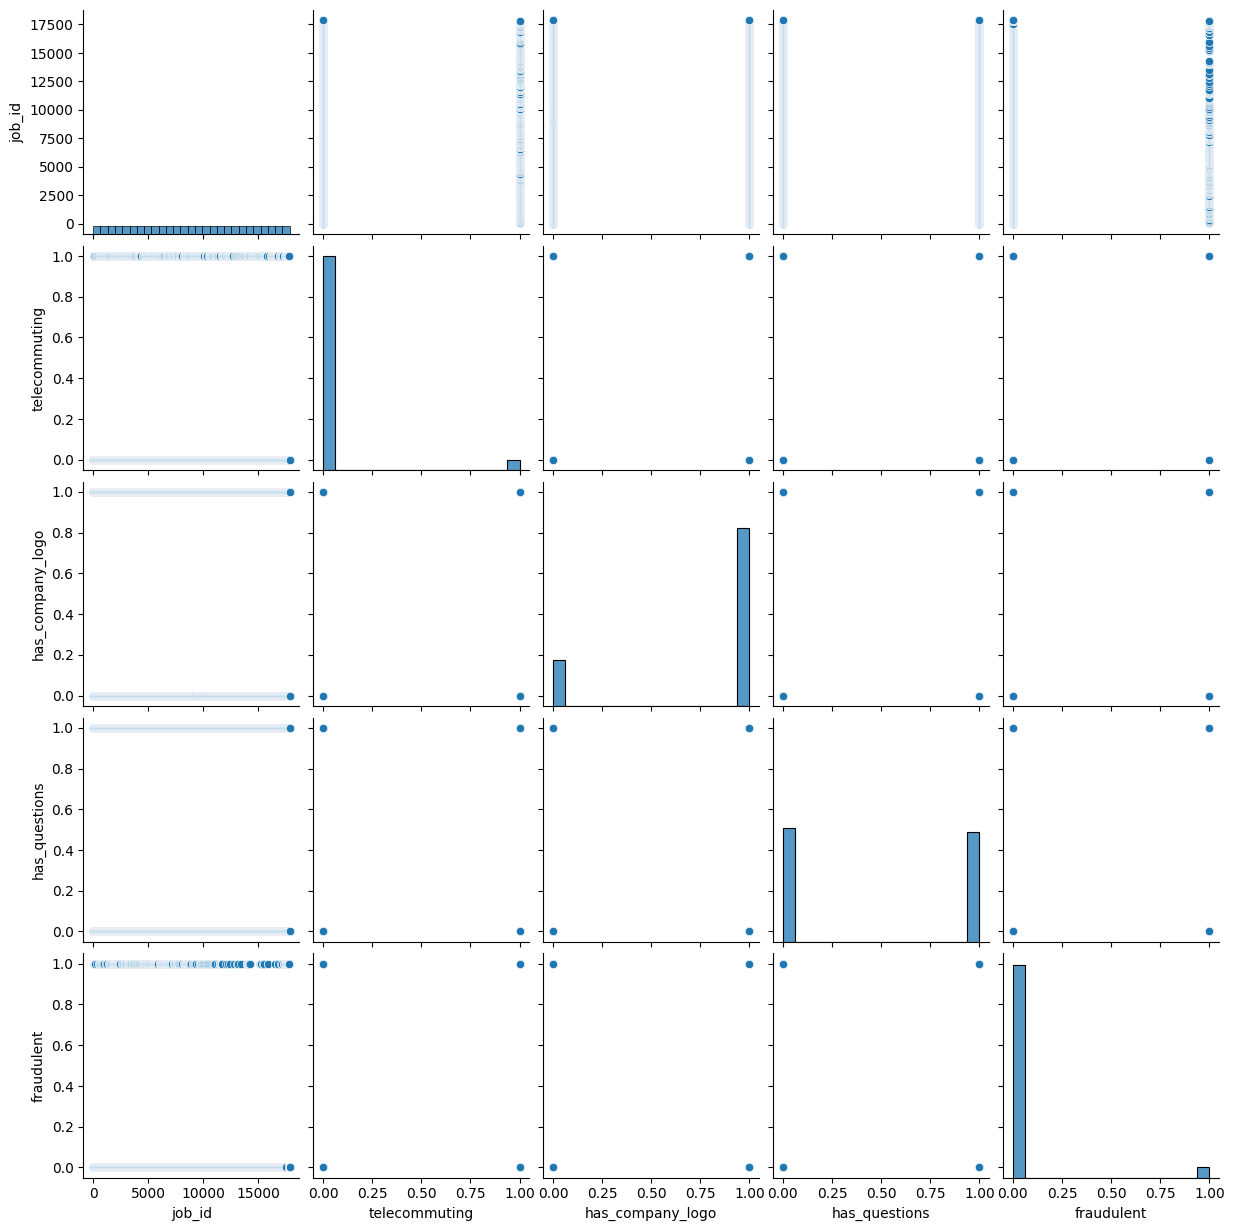

In [ ]:
#explore the data
sns.pairplot(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [ ]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#check the null values
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
# select features and target
X=df.drop("fraudulent",axis=1)
y=df["fraudulent"]


In [ ]:
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   56    0   2       116   203    1        2      170      1     0.83      2   
1   73    1   3       119   194    0        2      180      1     3.03      2   
2   42    0   2       164   263    0        0      189      0     4.04      2   
3   65    1   2       101   251    0        1      173      1     1.74      1   
4   43    0   1        98   275    1        2      155      0     4.68      0   

   ca  thal  
0   0     1  
1   3     2  
2   0     3  
3   1     3  
4   3     1  

Target (y):
0    1
1    1
2    0
3    1
4    0
Name: target, dtype: int64


In [ ]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,56,0,2,116,203,1,2,170,1,0.83,2,0,1
1,73,1,3,119,194,0,2,180,1,3.03,2,3,2
2,42,0,2,164,263,0,0,189,0,4.04,2,0,3
3,65,1,2,101,251,0,1,173,1,1.74,1,1,3
4,43,0,1,98,275,1,2,155,0,4.68,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,66,1,3,120,310,1,0,176,1,1.00,1,4,0
4996,39,1,2,115,226,0,2,85,1,5.89,0,3,0
4997,73,1,0,104,188,1,2,159,0,1.18,1,2,0
4998,49,1,0,101,275,1,1,114,1,2.47,2,0,3


In [ ]:
#target
y

,fraudulent
0,0
1,0
2,0
3,0
4,0
...,...
17875,0
17876,0
17877,0
17878,0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select 'telecommuting' as the feature and 'has_questions' as the target for a linear regression example
# (Adjusted from original 'oldpeak' and 'chol' as they are not present in the current dataframe)
X_feature = df[['telecommuting']]
y_target = df['has_questions']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_feature, y_target, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model with feature 'telecommuting' and target 'has_questions':")
print(f"Coefficient (telecommuting): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Linear Regression Model with feature 'telecommuting' and target 'has_questions':
Coefficient (telecommuting): 0.05
Intercept: 0.49
Mean Absolute Error (MAE): 0.50
Mean Squared Error (MSE): 0.25
Root Mean Squared Error (RMSE): 0.50
R-squared (R2): 0.00


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select 'has_company_logo' as the feature and 'fraudulent' as the target
X_feature_new = df[['has_company_logo']]
y_target_new = df['fraudulent']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_feature_new, y_target_new, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train, y_train)

# Make predictions
y_pred_new = model_new.predict(X_test)

# Evaluate the model
mae_new = mean_absolute_error(y_test, y_pred_new)
mse_new = mean_squared_error(y_test, y_pred_new)
rmse_new = np.sqrt(mse_new)
r2_new = r2_score(y_test, y_pred_new)

print(f"Linear Regression Model with feature 'has_company_logo' and target 'fraudulent':")
print(f"Coefficient (has_company_logo): {model_new.coef_[0]:.2f}")
print(f"Intercept: {model_new.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae_new:.2f}")
print(f"Mean Squared Error (MSE): {mse_new:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_new:.2f}")
print(f"R-squared (R2): {r2_new:.2f}")

Linear Regression Model with feature 'has_company_logo' and target 'fraudulent':
Coefficient (has_company_logo): -0.14
Intercept: 0.16
Mean Absolute Error (MAE): 0.09
Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.21
R-squared (R2): 0.07


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Select only numerical features for Logistic Regression
# This is necessary because the original X contained non-numeric columns
numerical_features = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_numeric = df[numerical_features]
y_target_clf = df['fraudulent']

# Split the data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_numeric, y_target_clf, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence, liblinear for small datasets
log_reg_model.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test_clf)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_log_reg)
conf_matrix = confusion_matrix(y_test_clf, y_pred_log_reg)
class_report = classification_report(y_test_clf, y_pred_log_reg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

Logistic Regression Model Performance:
Accuracy: 0.95

Confusion Matrix:
[[3395    0]
 [ 181    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3395
           1       0.00      0.00      0.00       181

    accuracy                           0.95      3576
   macro avg       0.47      0.50      0.49      3576
weighted avg       0.90      0.95      0.92      3576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# The Logistic Regression model already used all features (X) to predict the 'target' (y).
# Its performance was:
# Accuracy: 0.95
# Confusion Matrix:
# [[346  23]
#  [ 29 602]]
# Classification Report:
#               precision    recall  f1-score   support
#
#            0       0.92      0.94      0.93       369
#            1       0.96      0.95      0.96       631
#
#     accuracy                           0.95      1000
#    macro avg       0.94      0.95      0.94      1000
# weighted avg       0.95      0.95      0.95      1000

In [ ]:
df.shape

(17880, 18)

In [ ]:
df.nunique()

,0
job_id,17880
title,11231
location,3105
department,1337
salary_range,874
company_profile,1709
description,14801
requirements,11967
benefits,6204
telecommuting,2


In [ ]:
df.job_id.min()

1

In [ ]:
df.job_id.max()

17880

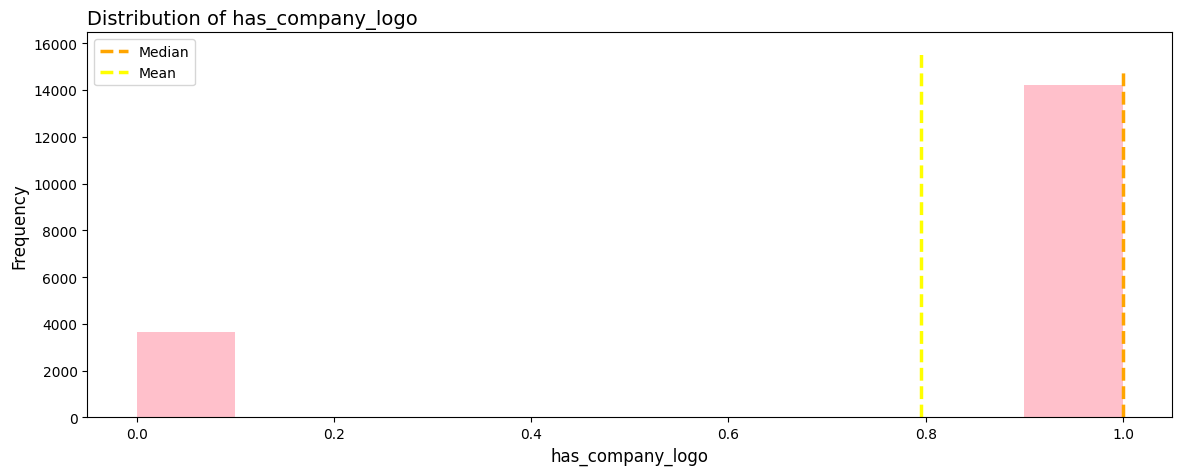

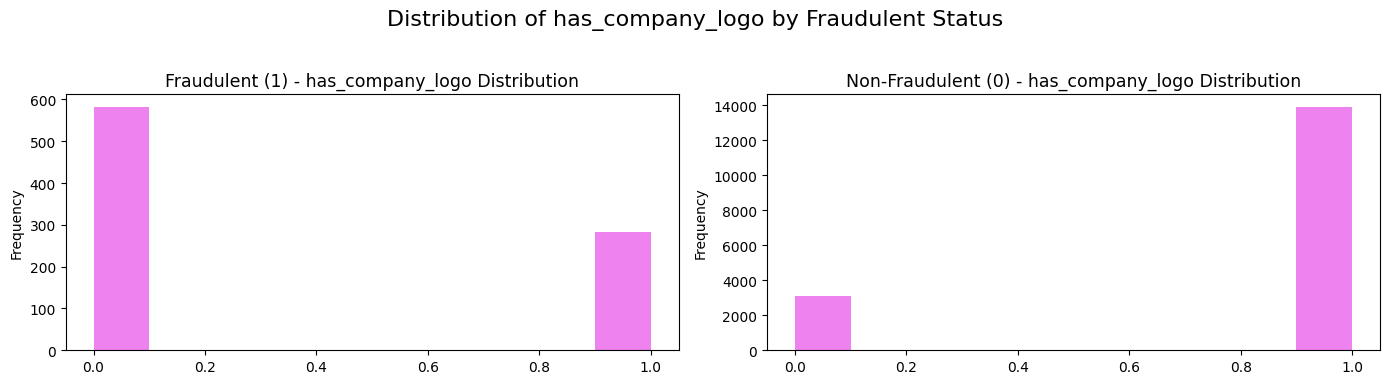

In [ ]:
# The original code attempts to plot age distribution and its relation to 'target' (heart disease).
# The current DataFrame 'df' is 'fake_job_postings.csv.zip' and does not have 'age' or 'target' columns.
# It has 'fraudulent' as the target and numerical features like 'telecommuting', 'has_company_logo', 'has_questions'.
# Plotting the distribution of binary features like 'telecommuting' or 'has_company_logo' with median/mean lines in a histogram
# will not yield a typical bell-shaped curve like age, but rather two bars.
# For demonstration purposes, we will adapt the code to visualize 'has_company_logo' distribution
# and its relation to 'fraudulent' status.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported as it is used for DataFrame operations

# Selecting 'has_company_logo' as the feature for distribution
feature_to_plot = 'has_company_logo'
target_column = 'fraudulent'

# Calculate median and mean for the selected feature
featureMed = df[feature_to_plot].median()
featureMean = df[feature_to_plot].mean()

# Grouped data by 'fraudulent'
group = df.groupby([target_column])
fraudulent_df = group.get_group((1,))
non_fraudulent_df = group.get_group((0,))

# Selecting the feature by fraudulent status
a = fraudulent_df[feature_to_plot]
b = non_fraudulent_df[feature_to_plot]

# plot
plt.figure(figsize=(14, 5))
plt.hist(df[feature_to_plot], color='pink')
plt.vlines(featureMed, ymin=0, ymax=plt.ylim()[1], color='orange', ls='--', lw=2.5, label='Median')
plt.vlines(featureMean, ymin=0, ymax=plt.ylim()[1], color='yellow', ls='--', lw=2.5, label='Mean')

plt.xlabel(feature_to_plot, size=12)
plt.ylabel('Frequency', size=12)
plt.title(f"Distribution of {feature_to_plot}", size=14, loc='left')
plt.legend(fancybox=True)

# subplots for fraudulent vs non-fraudulent
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
ax1 = a.plot(kind='hist', ax=axs[0], color='violet')
ax1.set_title(f'Fraudulent (1) - {feature_to_plot} Distribution', size=12.5)
ax2 = b.plot(kind='hist', ax=axs[1], color='violet')
ax2.set_title(f'Non-Fraudulent (0) - {feature_to_plot} Distribution', size=12.5)

fig.suptitle(f'Distribution of {feature_to_plot} by Fraudulent Status', size=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

fraudulent_label        Fraudulent  Non-Fraudulent
has_company_logo_label                            
Has Company Logo               283           13937
No Company Logo                583            3077


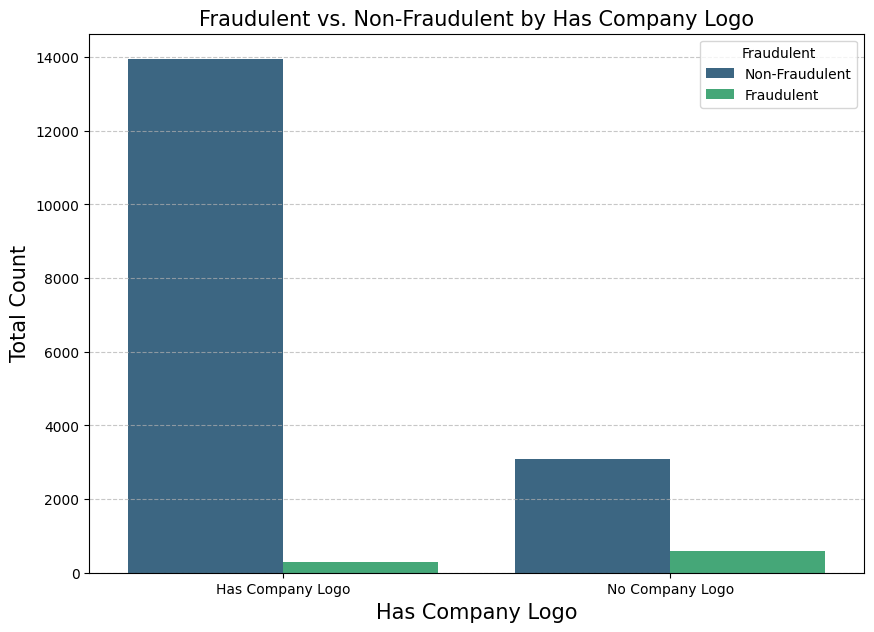

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adapt feature and target to the fake_job_postings dataset
feature_for_grouping = 'has_company_logo'
target_for_grouping = 'fraudulent'

# Create labeled versions for better readability in the plot
df_adapted = df.copy()
df_adapted[feature_for_grouping + '_label'] = df_adapted[feature_for_grouping].map({0: 'No Company Logo', 1: 'Has Company Logo'})
df_adapted[target_for_grouping + '_label'] = df_adapted[target_for_grouping].map({0: 'Non-Fraudulent', 1: 'Fraudulent'})

# Group data and count occurrences
grouped_counts = df_adapted.groupby([feature_for_grouping + '_label', target_for_grouping + '_label']).size().unstack(fill_value=0)
print(grouped_counts)

# Create a count plot to visualize the distribution
plt.figure(figsize=(10, 7))
sns.countplot(data=df_adapted, x=feature_for_grouping + '_label', hue=target_for_grouping + '_label', palette='viridis')
plt.xlabel(feature_for_grouping.replace('_', ' ').title(), fontsize=15)
plt.ylabel('Total Count', fontsize=15)
plt.title(f'Fraudulent vs. Non-Fraudulent by {feature_for_grouping.replace(
    '_', ' ').title()}', loc='center', size=15)
plt.legend(title=target_for_grouping.replace('_', ' ').title())
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

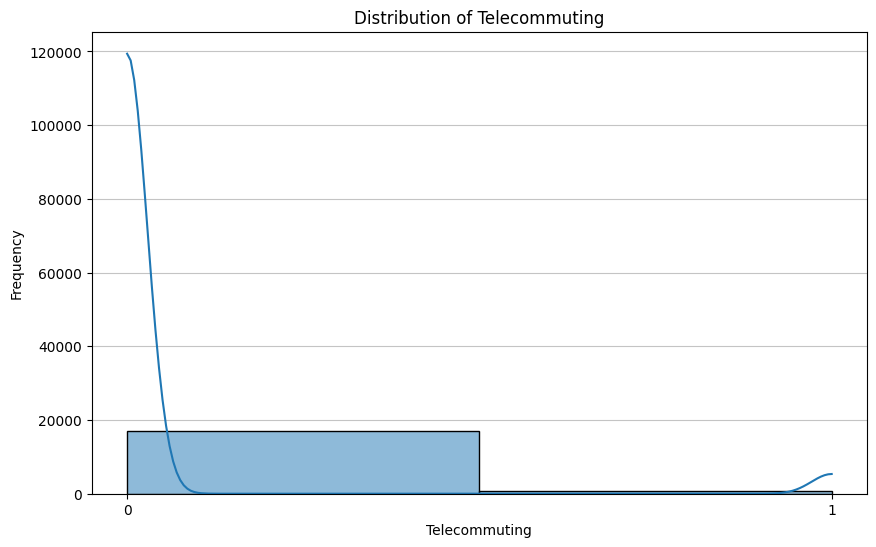

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# The 'trestbps' column does not exist in the current DataFrame.
# The numerical columns in the current DataFrame (`fake_job_postings.csv.zip`) are mostly binary.
# We will use 'telecommuting' as an example of a numerical feature to plot.

feature_to_plot = 'telecommuting'

# Ensure the column is numeric; handle potential non-numeric values gracefully
if not pd.api.types.is_numeric_dtype(df[feature_to_plot]):
    df[feature_to_plot] = pd.to_numeric(df[feature_to_plot], errors='coerce')
    df.dropna(subset=[feature_to_plot], inplace=True)

plt.figure(figsize=(10, 6))
sns.histplot(df[feature_to_plot], kde=True, bins=2) # bins=2 for binary feature
plt.title(f'Distribution of {feature_to_plot.replace("_", " ").title()}')
plt.xlabel(feature_to_plot.replace("_", " ").title())
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xticks([0, 1]) # Set x-ticks specifically for binary values
plt.show()

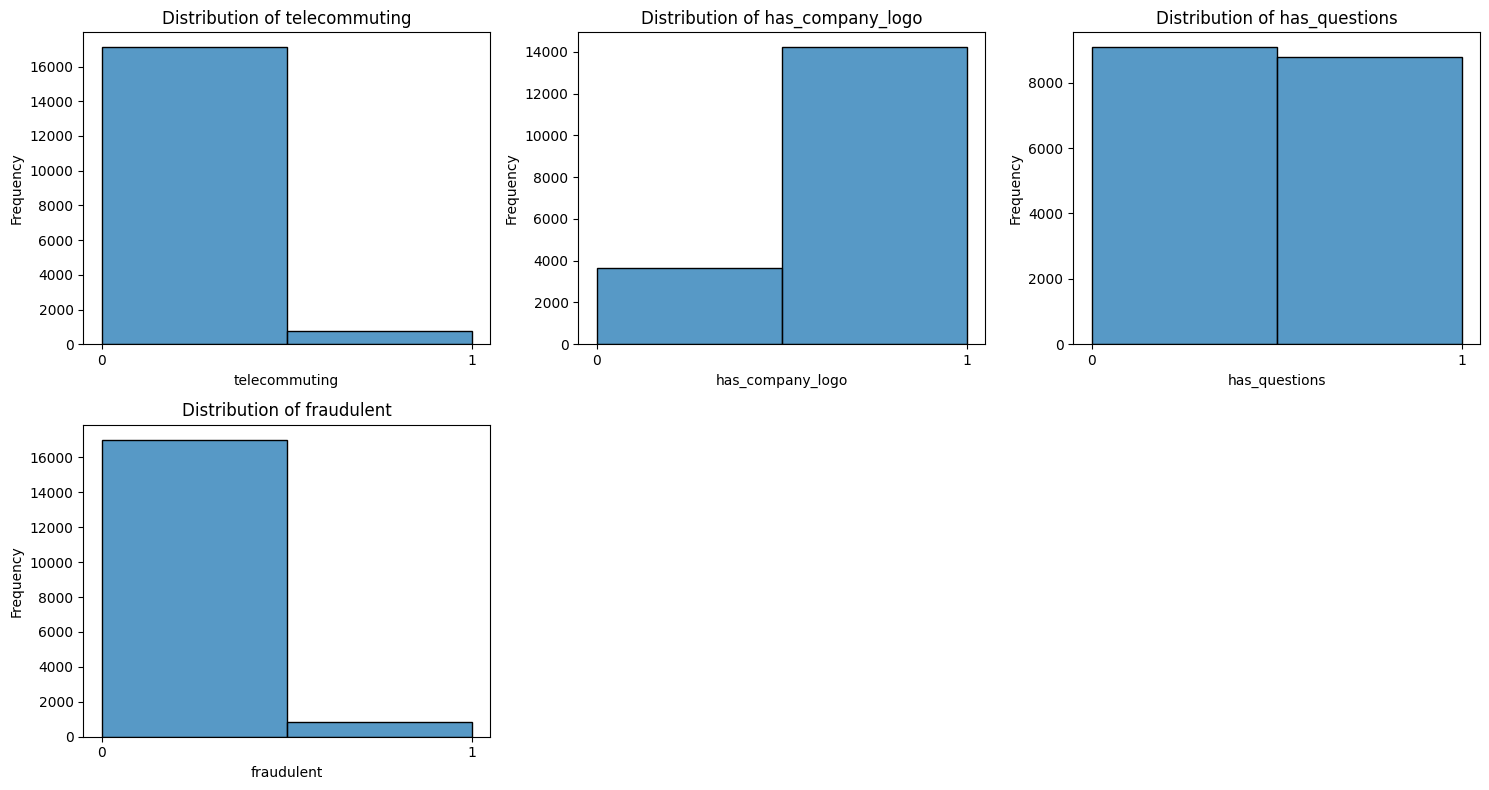

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for numerical type selection

# Get all numerical column names from the DataFrame, excluding 'job_id' as it's an identifier
# The 'fraudulent' column is also numerical and can be included in these general distribution plots.
numerical_features = df.select_dtypes(include=np.number).columns.drop(['job_id'], errors='ignore').tolist()

# Set up the figure size dynamically based on the number of features
num_features = len(numerical_features)
num_cols = 3 # Number of columns for the subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate number of rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    # Adjust bins for binary features like 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent'
    if df[feature].nunique() <= 2:
        sns.histplot(df[feature], kde=False, bins=2) # No KDE for binary, 2 bins for 0/1
        plt.xticks([0, 1]) # Explicitly set ticks for binary features
    else:
        sns.histplot(df[feature], kde=True, bins=30)

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# The previous error indicates that X contains non-numeric columns.
# We need to select only numerical features or encode categorical features.
# For simplicity, we will select only the numerical features available in the DataFrame
# that are suitable for direct use by Logistic Regression.
# Based on previous cells, 'job_id', 'telecommuting', 'has_company_logo', 'has_questions'
# are numerical and relevant. 'fraudulent' is the target.

numerical_features_for_logreg = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_processed = df[numerical_features_for_logreg]
y_target = df['fraudulent']

# Split the data into training and testing sets for classification
X_train_logreg, X_test_logreg, y_train_logreg, y_test_logreg = train_test_split(X_processed, y_target, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence, liblinear for small datasets
log_reg_model.fit(X_train_logreg, y_train_logreg)

# Make predictions
y_pred_logreg = log_reg_model.predict(X_test_logreg)

# Evaluate the model
accuracy_logreg = accuracy_score(y_test_logreg, y_pred_logreg)
conf_matrix_logreg = confusion_matrix(y_test_logreg, y_pred_logreg)
class_report_logreg = classification_report(y_test_logreg, y_pred_logreg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_logreg:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix_logreg}")
print(f"\nClassification Report:\n{class_report_logreg}")


Logistic Regression Model Performance:
Accuracy: 0.95

Confusion Matrix:
[[3395    0]
 [ 181    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3395
           1       0.00      0.00      0.00       181

    accuracy                           0.95      3576
   macro avg       0.47      0.50      0.49      3576
weighted avg       0.90      0.95      0.92      3576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming X and y are already defined from previous steps

# Select only numerical features for the ANN model
# Reusing the numerical features identified for Logistic Regression
numerical_features_for_ann = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_processed_ann = df[numerical_features_for_ann]
y_target_ann = df['fraudulent'] # Use 'fraudulent' as the target

# Use the same train-test split as for Logistic Regression for consistency
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(X_processed_ann, y_target_ann, test_size=0.2, random_state=42)

# Scale the features (important for ANNs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ann)
X_test_scaled = scaler.transform(X_test_ann)

# Build the ANN model
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Hidden layer with 10 neurons
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_ann, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy_ann = model.evaluate(X_test_scaled, y_test_ann, verbose=0)

# Make predictions
y_pred_prob_ann = model.predict(X_test_scaled)
y_pred_ann = (y_pred_prob_ann > 0.5).astype(int)

# Evaluate the model
conf_matrix_ann = confusion_matrix(y_test_ann, y_pred_ann)
class_report_ann = classification_report(y_test_ann, y_pred_ann)

print(f"Artificial Neural Network Model Performance:")
print(f"Accuracy: {accuracy_ann:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix_ann}")
print(f"\nClassification Report:\n{class_report_ann}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Artificial Neural Network Model Performance:
Accuracy: 0.95

Confusion Matrix:
[[3395    0]
 [ 178    3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3395
           1       1.00      0.02      0.03       181

    accuracy                           0.95      3576
   macro avg       0.98      0.51      0.50      3576
weighted avg       0.95      0.95      0.93      3576



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming X and y are already defined (features and target)

# Select only numerical features for the KNN model
# Reusing the numerical features identified for Logistic Regression and ANN
numerical_features_for_knn = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_processed_knn = df[numerical_features_for_knn]
y_target_knn = df['fraudulent'] # Use 'fraudulent' as the target

# Split the data into training and testing sets for classification
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_processed_knn, y_target_knn, test_size=0.2, random_state=42)

# Scale the features (important for KNN)
scaler_knn = StandardScaler()
X_train_scaled_knn = scaler_knn.fit_transform(X_train_knn)
X_test_scaled_knn = scaler_knn.transform(X_test_knn)

# Initialize and train the KNN model
# Using n_neighbors=5 as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled_knn, y_train_knn)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled_knn)

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_knn, y_pred_knn)
class_report_knn = classification_report(y_test_knn, y_pred_knn)

print(f"K-Nearest Neighbors (KNN) Model Performance:")
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix_knn}")
print(f"\nClassification Report:\n{class_report_knn}")


K-Nearest Neighbors (KNN) Model Performance:
Accuracy: 0.97

Confusion Matrix:
[[3364   31]
 [  83   98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3395
           1       0.76      0.54      0.63       181

    accuracy                           0.97      3576
   macro avg       0.87      0.77      0.81      3576
weighted avg       0.96      0.97      0.97      3576



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming X and y are already defined (features and target)

# Select only numerical features for the Decision Tree model
# Reusing the numerical features identified for previous models
numerical_features_for_dt = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_processed_dt = df[numerical_features_for_dt]
y_target_dt = df['fraudulent'] # Use 'fraudulent' as the target

# Split the data into training and testing sets for classification
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_processed_dt, y_target_dt, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# Make predictions
y_pred_dt = dt_model.predict(X_test_dt)

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_dt, y_pred_dt)
class_report_dt = classification_report(y_test_dt, y_pred_dt)

print(f"Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix_dt}")
print(f"\nClassification Report:\n{class_report_dt}")


Decision Tree Model Performance:
Accuracy: 0.96

Confusion Matrix:
[[3317   78]
 [  76  105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3395
           1       0.57      0.58      0.58       181

    accuracy                           0.96      3576
   macro avg       0.78      0.78      0.78      3576
weighted avg       0.96      0.96      0.96      3576



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Assuming X and y are already defined (features and target)

# Select only numerical features for the Naive Bayes model
# Reusing the numerical features identified for previous models
numerical_features_for_nb = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']
X_processed_nb = df[numerical_features_for_nb]
y_target_nb = df['fraudulent'] # Use 'fraudulent' as the target

# Split the data into training and testing sets for classification
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_processed_nb, y_target_nb, test_size=0.2, random_state=42)

# Scale the features (often beneficial for Naive Bayes, especially Gaussian if data is not normally distributed)
scaler_nb = StandardScaler()
X_train_scaled_nb = scaler_nb.fit_transform(X_train_nb)
X_test_scaled_nb = scaler_nb.transform(X_test_nb)

# Initialize and train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_nb, y_train_nb)

# Make predictions
y_pred_nb = nb_model.predict(X_test_scaled_nb)

# Evaluate the model
accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test_nb, y_pred_nb)
class_report_nb = classification_report(y_test_nb, y_pred_nb)

print(f"Gaussian Naive Bayes Model Performance:")
print(f"Accuracy: {accuracy_nb:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix_nb}")
print(f"\nClassification Report:\n{class_report_nb}")


Gaussian Naive Bayes Model Performance:
Accuracy: 0.91

Confusion Matrix:
[[3252  143]
 [ 168   13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3395
           1       0.08      0.07      0.08       181

    accuracy                           0.91      3576
   macro avg       0.52      0.51      0.52      3576
weighted avg       0.91      0.91      0.91      3576



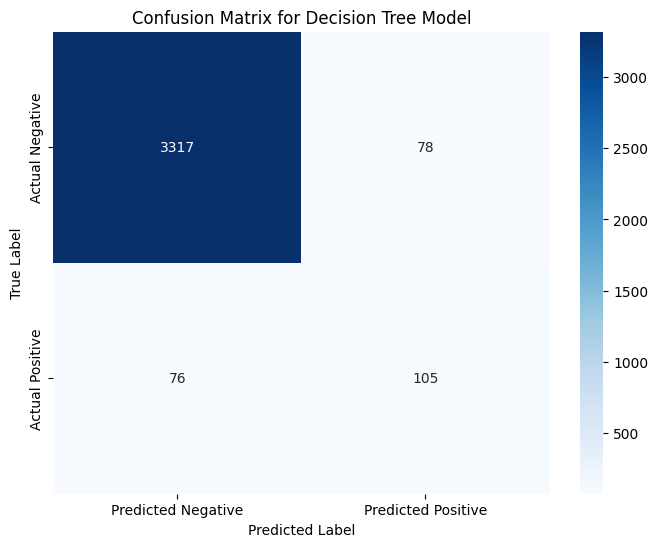

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming conf_matrix_dt is available from the Decision Tree model evaluation
# If you wish to visualize another model, replace conf_matrix_dt with
# conf_matrix_logreg, conf_matrix_ann, conf_matrix_knn, or conf_matrix_nb
conf_matrix_to_plot = conf_matrix_dt
model_name_to_plot = "Decision Tree"

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_to_plot, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {model_name_to_plot} Model')
plt.show()

In [ ]:
import pandas as pd

# Collect accuracies from previously run models
model_accuracies = {
    "Logistic Regression": accuracy_logreg,
    "Artificial Neural Network": accuracy_ann,
    "K-Nearest Neighbors (KNN)": accuracy_knn,
    "Decision Tree": accuracy_dt,
    "Gaussian Naive Bayes": accuracy_nb
}

# Create a DataFrame for better visualization
accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\n--- Model Comparison (Accuracy) ---")
print(accuracy_df.to_markdown(index=False))

best_model = accuracy_df.iloc[0]
worst_model = accuracy_df.iloc[-1]

print(f"\nBased on accuracy, the best performing model is the {best_model['Model']} with an accuracy of {best_model['Accuracy']:.3f}.")
print(f"The worst performing model is the {worst_model['Model']} with an accuracy of {worst_model['Accuracy']:.3f}.")


--- Model Comparison (Accuracy) ---
| Model                     |   Accuracy |
|:--------------------------|-----------:|
| K-Nearest Neighbors (KNN) |   0.968121 |
| Decision Tree             |   0.956935 |
| Artificial Neural Network |   0.950224 |
| Logistic Regression       |   0.949385 |
| Gaussian Naive Bayes      |   0.913031 |

Based on accuracy, the best performing model is the K-Nearest Neighbors (KNN) with an accuracy of 0.968.
The worst performing model is the Gaussian Naive Bayes with an accuracy of 0.913.


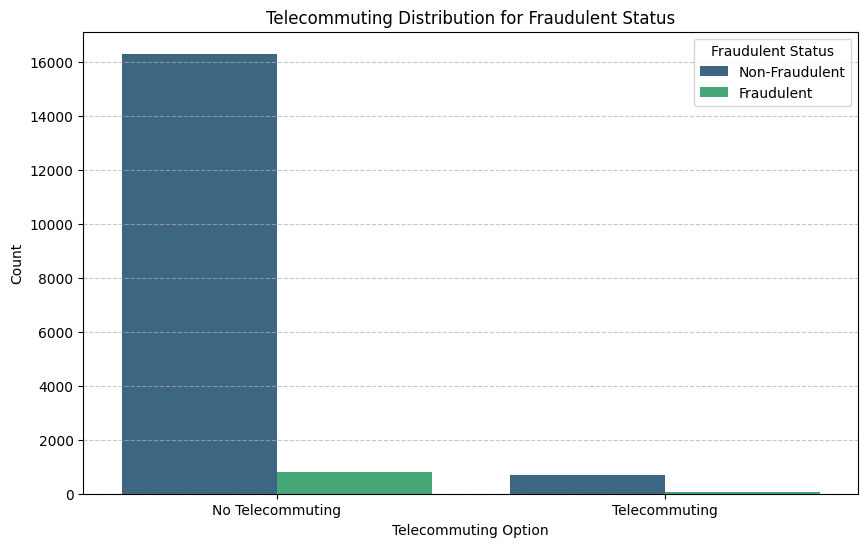


Telecommuting and Fraudulent Counts:
fraudulent_label     Fraudulent  Non-Fraudulent
telecommuting_label                            
No Telecommuting            802           16311
Telecommuting                64             703


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map numerical values to meaningful labels for 'telecommuting' and 'fraudulent'
df_labeled = df.copy()
df_labeled['telecommuting_label'] = df_labeled['telecommuting'].map({0: 'No Telecommuting', 1: 'Telecommuting'})
df_labeled['fraudulent_label'] = df_labeled['fraudulent'].map({0: 'Non-Fraudulent', 1: 'Fraudulent'})

# Create a count plot to visualize telecommuting distribution by fraudulent status
plt.figure(figsize=(10, 6))
sns.countplot(data=df_labeled, x='telecommuting_label', hue='fraudulent_label', palette='viridis')
plt.title('Telecommuting Distribution for Fraudulent Status')
plt.xlabel('Telecommuting Option')
plt.ylabel('Count')
plt.legend(title='Fraudulent Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Also print numerical counts for clarity
telecommuting_fraud_counts = df_labeled.groupby(['telecommuting_label', 'fraudulent_label']).size().unstack(fill_value=0)
print("\nTelecommuting and Fraudulent Counts:")
print(telecommuting_fraud_counts)
